# Applied Exercise 6 - Wage Data: Polynomial Regression and Step Functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ISLP import load_data
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
import warnings
warnings.filterwarnings("ignore")

In [2]:
Wage = load_data("Wage")
X = Wage[["age"]]
y = Wage["wage"]

print("=" * 60)
print("WAGE DATA")
print("=" * 60)
print("Observations:", len(Wage))

WAGE DATA
Observations: 3000



POLYNOMIAL REGRESSION
 Degree      CV_MSE
      1 1677.205121
      2 1601.356479
      3 1596.246418
      4 1595.074236
      5 1595.071099
      6 1594.868498
      7 1593.864488
      8 1593.448852
      9 1596.119186
     10 1603.719084

Best polynomial degree = 8


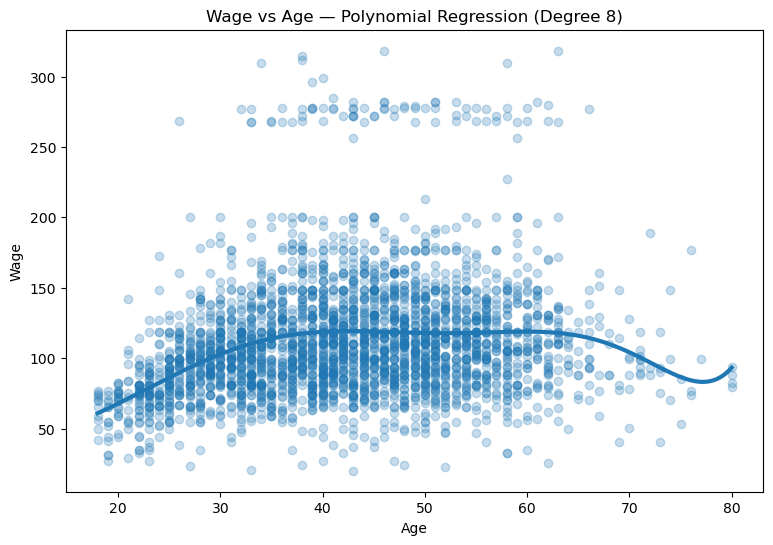

In [3]:
print("\n" + "=" * 60)
print("POLYNOMIAL REGRESSION")
print("=" * 60)

kf = KFold(n_splits=10, shuffle=True, random_state=1)
poly_results = []
for degree in range(1, 11):
    model = Pipeline([("poly", PolynomialFeatures(degree=degree, include_bias=False)), ("lr", LinearRegression())])
    mse = -cross_val_score(model, X, y, cv=kf, scoring="neg_mean_squared_error").mean()
    poly_results.append([degree, mse])

poly_results = pd.DataFrame(poly_results, columns=["Degree", "CV_MSE"])
best_degree = int(poly_results.loc[poly_results["CV_MSE"].idxmin(), "Degree"])

print(poly_results.to_string(index=False))
print(f"\nBest polynomial degree = {best_degree}")

poly_model = Pipeline([("poly", PolynomialFeatures(degree=best_degree, include_bias=False)), ("lr", LinearRegression())])
poly_model.fit(X, y)

age_grid = np.linspace(X["age"].min(), X["age"].max(), 500).reshape(-1, 1)
wage_pred = poly_model.predict(age_grid)

plt.figure(figsize=(9, 6))
plt.scatter(Wage["age"], Wage["wage"], alpha=0.25)
plt.plot(age_grid, wage_pred, linewidth=3)
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title(f"Wage vs Age — Polynomial Regression (Degree {best_degree})")
plt.show()

In [4]:
print("\n" + "=" * 60)
print("ANOVA COMPARISON")
print("=" * 60)

anova_models = []
for degree in range(1, 6):
    X_poly = np.column_stack([X["age"] ** i for i in range(1, degree + 1)])
    X_poly = sm.add_constant(X_poly)
    anova_models.append(sm.OLS(y, X_poly).fit())

anova_table = anova_lm(*anova_models)
print(anova_table)


ANOVA COMPARISON
   df_resid           ssr  df_diff        ss_diff           F        Pr(>F)
0    2998.0  5.022216e+06      0.0            NaN         NaN           NaN
1    2997.0  4.793430e+06      1.0  228786.010128  143.593107  2.363850e-32
2    2996.0  4.777674e+06      1.0   15755.693664    9.888756  1.679202e-03
3    2995.0  4.771604e+06      1.0    6070.152124    3.809813  5.104620e-02
4    2994.0  4.770322e+06      1.0    1282.563017    0.804976  3.696820e-01


- Polynomial regression models of degrees 1 through 10 and used 10-fold cross-validation to select the degree. Cross-validation selected a polynomial of degree 8, which had the lowest CV MSE of 1593.45. However, the improvement after degree 3 was very small. The CV MSE decreased from 1596.25 for degree 3 to 1593.45 for degree 8.
- The ANOVA results provide a somewhat different conclusion. The quadratic and cubic terms were statistically significant, with p-values of approximately 2.36 × 10^-32 and 0.00168, respectively. The fourth-degree term had a p-value of approximately 0.051 (borderline at 95% CI), while the fifth-degree term was not significant (p ≈ 0.370).
- Thus, ANOVA suggests that a cubic model may be sufficient, whereas cross-validation selected degree 8. This difference occurs because ANOVA tests statistical significance of additional terms, whereas cross-validation evaluates predictive performance.


STEP FUNCTION
 Number_of_Cuts      CV_MSE
              2 1732.217912
              3 1683.428414
              4 1636.091836
              5 1631.093416
              6 1623.889511
              7 1612.766774
              8 1602.143809
              9 1610.918506
             10 1606.639281

Best number of cuts = 8


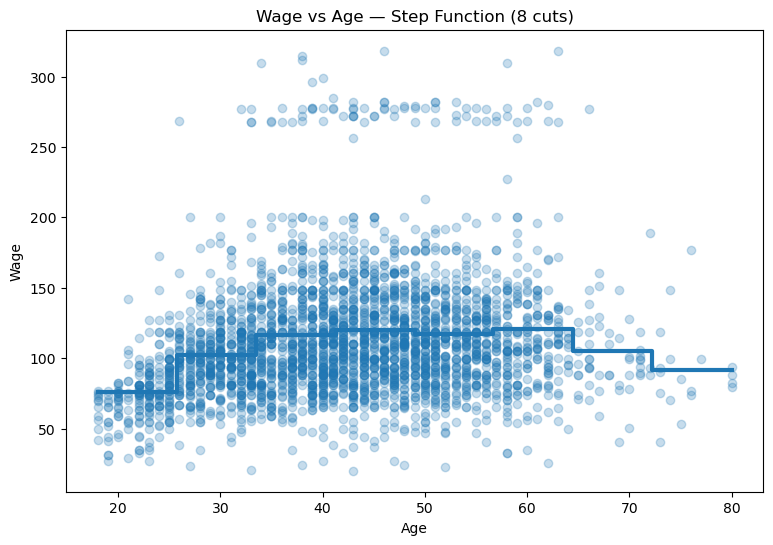

In [5]:
class StepFunction(BaseEstimator, TransformerMixin):
    def __init__(self, n_cuts=5):
        self.n_cuts = n_cuts

    def fit(self, X, y=None):
        x = np.asarray(X).ravel()
        self.bins_ = np.linspace(x.min(), x.max(), self.n_cuts + 1)
        return self

    def transform(self, X):
        x = np.asarray(X).ravel()
        groups = np.digitize(x, self.bins_[1:-1])
        return np.eye(self.n_cuts)[groups]

print("\n" + "=" * 60)
print("STEP FUNCTION")
print("=" * 60)

step_results = []
for cuts in range(2, 11):
    model = Pipeline([("step", StepFunction(n_cuts=cuts)), ("lr", LinearRegression())])
    mse = -cross_val_score(model, X, y, cv=kf, scoring="neg_mean_squared_error").mean()
    step_results.append([cuts, mse])

step_results = pd.DataFrame(step_results, columns=["Number_of_Cuts", "CV_MSE"])
best_cuts = int(step_results.loc[step_results["CV_MSE"].idxmin(), "Number_of_Cuts"])

print(step_results.to_string(index=False))
print(f"\nBest number of cuts = {best_cuts}")

step_model = Pipeline([("step", StepFunction(n_cuts=best_cuts)), ("lr", LinearRegression())])
step_model.fit(X, y)

age_grid_flat = np.linspace(X["age"].min(), X["age"].max(), 500)
step_pred = step_model.predict(age_grid_flat.reshape(-1, 1))

plt.figure(figsize=(9, 6))
plt.scatter(Wage["age"], Wage["wage"], alpha=0.25)
plt.plot(age_grid_flat, step_pred, linewidth=3, drawstyle="steps-mid")
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title(f"Wage vs Age — Step Function ({best_cuts} cuts)")
plt.show()

- Step-function models using between 2 and 10 cuts and used 10-fold cross-validation to select the optimal number of cuts which is 8. Cross-validation selected a step function with 8 cuts, which produced the lowest CV MSE of approximately 1602.14.
- The CV error decreased as the number of cuts increased from 2 to 8, but increased again when using 9 or 10 cuts. This suggests that using too few cuts does not capture enough of the relationship between age and wage, while additional cuts beyond 8 provide little benefit and may begin to overfit the data.
- The step-function model had a slightly higher CV MSE than the best polynomial model, suggesting that the polynomial regression provides somewhat better predictive performance for wage based on age.